# Self-Refine Self-Play Analysis

Does letting a model internally draft, critique, and refine its response improve its negotiation outcomes in self-play?

This notebook compares **self-refine** (generate → critique → refine → send) against **baseline** (generate → send) under identical conditions.  Both players always use the same model; the only thing that varies is the strategy.

Set `MODEL_SIZE` below to switch between size tiers. 

In [1]:
MODEL_SIZE = "very_small"   # "small" | "medium"

In [2]:
import os, sys, re, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({"font.size": 22})
sns.set(font_scale=2.4)

def _find_repo_root():
    cur = Path(os.getcwd()).resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "explorer" / "analysis" / "common.py").exists():
            return parent
    raise RuntimeError("Could not locate repo root (explorer/analysis/common.py not found)")

_REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(_REPO_ROOT / "explorer"))
from analysis.common import LOGS_ROOT, clean_name, resource_value  # noqa: E402

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

SELF_REFINE_ROOT = Path(LOGS_ROOT) / "self_refine"
GAMES = {
    "trading_self_refine_v1":   "Trading",
    "ultimatum_self_refine_v1": "Ultimatum",
    "buysell_self_refine_v1":   "BuySell",
}

# Symmetric strategies (used in §1–§5)
STRATEGIES = ["baseline", "self_refine"]
STRATEGY_COLORS = {
    "baseline":    "#7f7f7f",
    "self_refine": "#d62728",
}

# Cross-play conditions (used in §6)
COND_ORDER = ["base × base", "refine × refine", "base × refine", "refine × base"]
COND_COLORS = {
    "base × base":     "#7f7f7f",
    "refine × refine": "#d62728",
    "base × refine":   "#1f77b4",
    "refine × base":   "#ff7f0e",
}

def cond_label(p1: str, p2: str) -> str:
    s = {"default": "base", "self_refine": "refine"}
    return f"{s.get(p1, p1)} × {s.get(p2, p2)}"

SIZE_LABEL = MODEL_SIZE.replace("_", " ").title()
print(f"Model size : {SIZE_LABEL}")
print(f"Logs root  : {SELF_REFINE_ROOT}")


Model size : Very Small
Logs root  : /home/adriano/Desktop/MultiAgent-Negotiation/.logs/self_refine


## Experimental Design

| Dimension | Value |
|--|-|
| **Strategies** | `baseline` (one-shot) vs `self_refine` (draft → feedback → refine → send) |
| **Games** | Trading, Ultimatum, BuySell |
| **Play mode** | Self-play (same model on both sides, same strategy on both sides) |
| **Models (medium)** | gemma-3-27b-it, mistral-small-3.2-24b, qwen3.5-27b |
| **Models (small)** | gemma-3-12b-it, ministral-3-14b-instruct, qwen3-14b |


In [3]:
STRATEGY_SUFFIX_RE = re.compile(r"_([a-z_]+)P1_([a-z_]+)P2$")

def _strip_strategy_suffix(piece: str):
    m = STRATEGY_SUFFIX_RE.search(piece)
    if m:
        return piece[:m.start()], m.group(1), m.group(2)
    return piece, None, None

def _synth_strategy(p1: str, p2: str) -> str:
    if p1 == p2 == "default":
        return "baseline"
    if p1 == p2:
        return p1
    return f"{p1}P1_{p2}P2"

def parse_run_path(game_state_path: Path) -> dict:
    parts = game_state_path.parts
    idx = parts.index("self_refine")
    experiment, size = parts[idx + 1], parts[idx + 2]
    p1_strategy = p2_strategy = None
    for piece in reversed(parts[idx + 3 : -1]):
        _, p1, p2 = _strip_strategy_suffix(piece)
        if p1:
            p1_strategy, p2_strategy = p1, p2
            break
    strategy = _synth_strategy(p1_strategy, p2_strategy) if p1_strategy else None
    run_id = parts[-2]
    pair, _, _ = _strip_strategy_suffix(parts[idx + 3])
    return dict(
        experiment=experiment, size=size, pair=pair,
        strategy=strategy,
        p1_strategy=p1_strategy, p2_strategy=p2_strategy,
        run_id=run_id,
    )


def extract_outcome(game_prefix: str, data: dict) -> dict:
    gs = data["game_state"]
    last = gs[-1]
    completed = last.get("current_iteration") == "END"
    turn_states = [s for s in gs if s.get("current_iteration") not in ("START", "END")]
    out = dict(
        game=game_prefix,
        completed=completed,
        num_turns=len(turn_states),
        total_parse_retries=data.get("total_parse_retries", 0),
        model_1=data["players"][0].get("model_id", data["players"][0].get("model")),
        model_2=data["players"][1].get("model_id", data["players"][1].get("model")),
    )
    if not completed:
        return out
    summary = last.get("summary", {})
    out["final_response"] = summary.get("final_response")
    out["deal"] = summary.get("final_response") == "ACCEPT"
    if game_prefix == "BuySell":
        oc = summary.get("player_outcome", [None, None])
        out["payoff_1"] = oc[0] if oc[0] is not None else np.nan
        out["payoff_2"] = oc[1] if oc[1] is not None else np.nan
    else:
        init = summary.get("initial_resources")
        final = summary.get("final_resources")
        if init and final:
            d1 = resource_value(final[0]) - resource_value(init[0])
            d2 = resource_value(final[1]) - resource_value(init[1])
            if game_prefix == "Ultimatum":
                # Proposer starts at $100; convert delta → dollars they walk away with.
                # A REJECT leaves both at 0.
                d1 = d1 + 100
                if d1 == 100:
                    d1 = 0
            out["payoff_1"] = d1
            out["payoff_2"] = d2
    return out


def load_all_runs():
    rows = []
    for exp_dir, game_name in GAMES.items():
        root = SELF_REFINE_ROOT / exp_dir
        if not root.exists():
            continue
        for gs_path in root.rglob("game_state.json"):
            try:
                meta = parse_run_path(gs_path)
                if meta["strategy"] is None:
                    continue
                with open(gs_path) as f:
                    data = json.load(f)
                out = extract_outcome(game_name, data)
                rows.append({**meta, **out, "run_dir": str(gs_path.parent)})
            except Exception:
                continue
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["model_short"] = df["model_1"].map(clean_name)
    df["surplus"] = df["payoff_1"].fillna(0) + df["payoff_2"].fillna(0)
    df["cond"] = df.apply(
        lambda r: cond_label(r["p1_strategy"], r["p2_strategy"])
        if pd.notna(r.get("p1_strategy")) else None,
        axis=1,
    )
    return df


In [4]:
df_all = load_all_runs()
df = df_all[df_all["size"] == MODEL_SIZE].copy() if not df_all.empty else df_all

if df.empty:
    raise FileNotFoundError(
        f"No self-refine runs found for MODEL_SIZE={MODEL_SIZE!r}. "
        f"Check {SELF_REFINE_ROOT}."
    )

# Symmetric strategies only (both players same strategy) — used for §1–§5
sym_df = df[df["strategy"].isin(STRATEGIES)].copy()

print(f"{'Game':<12} {'Model':<36} {'Strategy':<12} {'Total':>6} {'Completed':>10}")
print("_" * 80)
for game in sorted(sym_df["game"].unique()):
    for model in sorted(sym_df[sym_df["game"] == game]["model_short"].unique()):
        for strat in STRATEGIES:
            sub = sym_df[
                (sym_df["game"] == game)
                & (sym_df["model_short"] == model)
                & (sym_df["strategy"] == strat)
            ]
            if sub.empty:
                continue
            total = len(sub)
            done = int(sub["completed"].sum())
            print(f"{game:<12} {model:<36} {strat:<12} {total:>6} {done:>10}")
print(f"\nTotal rows for {SIZE_LABEL}: {len(df)}  (symmetric only: {len(sym_df)})")


Game         Model                                Strategy      Total  Completed
________________________________________________________________________________
BuySell      Ministral-3-8B-2512                  baseline         30         25
BuySell      Ministral-3-8B-2512                  self_refine      30         23
BuySell      Qwen3.5-9B                           baseline         30         28
BuySell      Qwen3.5-9B                           self_refine      30         30
BuySell      gemma-3-4b-it                        baseline         30         12
BuySell      gemma-3-4b-it                        self_refine      30          5
Trading      Ministral-3-8B-2512                  baseline         30         28
Trading      Ministral-3-8B-2512                  self_refine      30         30
Trading      Qwen3.5-9B                           baseline         30         21
Trading      Qwen3.5-9B                           self_refine       9          8
Trading      gemma-3-4b-it  

## 1. Game Completion Rates

A game is **completed** if it reached the `END` iteration; otherwise the run hit an `ERROR` or timed out with an unparseable message.  Self-refine issues *more* LLM calls per turn (draft + feedback + refine), so it has more opportunities for a malformed message to abort the run we want to know whether that cost actually materialises.


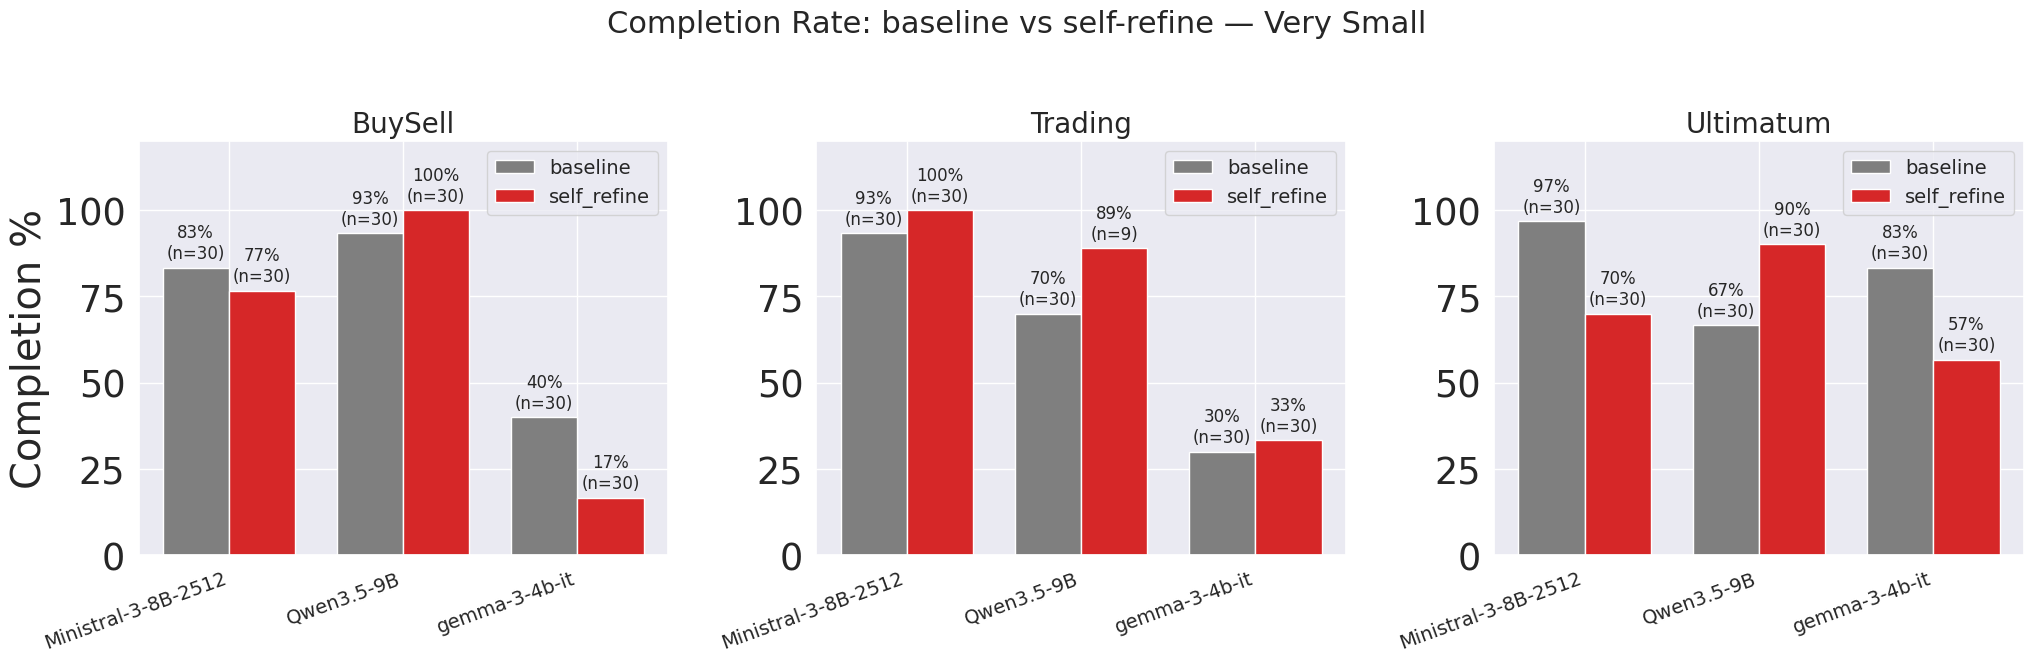

In [5]:
agg = sym_df.groupby(["game", "model_short", "strategy"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg["pct"] = agg["completed"] / agg["total"] * 100

games = sorted(agg["game"].unique())
fig, axes = plt.subplots(1, len(games), figsize=(7 * len(games), 7), squeeze=False)

for ax, game in zip(axes[0], games):
    sub = agg[agg["game"] == game]
    models = sorted(sub["model_short"].unique())
    x = np.arange(len(models))
    width = 0.38
    for i, strat in enumerate(STRATEGIES):
        pct = [sub[(sub["model_short"] == m) & (sub["strategy"] == strat)]["pct"].sum()
               for m in models]
        totals = [int(sub[(sub["model_short"] == m) & (sub["strategy"] == strat)]["total"].sum())
                  for m in models]
        bars = ax.bar(x + (i - 0.5) * width, pct, width,
                      label=strat, color=STRATEGY_COLORS[strat])
        for bar, v, n in zip(bars, pct, totals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5,
                    f"{v:.0f}%\n(n={n})", ha="center", va="bottom", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14, rotation=20, ha="right")
    ax.set_ylim(0, 120)
    ax.set_ylabel("Completion %" if ax is axes[0][0] else "")
    ax.set_title(game, fontsize=20)
    ax.legend(fontsize=14, loc="upper right")

fig.suptitle(f"Completion Rate: baseline vs self-refine — {SIZE_LABEL}", fontsize=22)
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_completion_rates.pdf", bbox_inches="tight")
plt.show()


Self-refine improves completion most clearly for Mistral and Qwen. With Gemma it actually reduces the completion rate for Trading and Ultimatum

## 2. Negotiation Outcomes

Among games that completed, does self-refine change what the agents walk away with?

- **Trading** — resource delta relative to each player's starting inventory (zero-sum under 1:1 valuation).
- **Ultimatum** — dollars each player ends up with: proposer keeps $100 − transferred, responder receives the transfer.  Rejected deals give both $0.
- **BuySell** — seller / buyer profit (`summary.player_outcome`).  Positive = profit, 0 = no-deal or break-even.


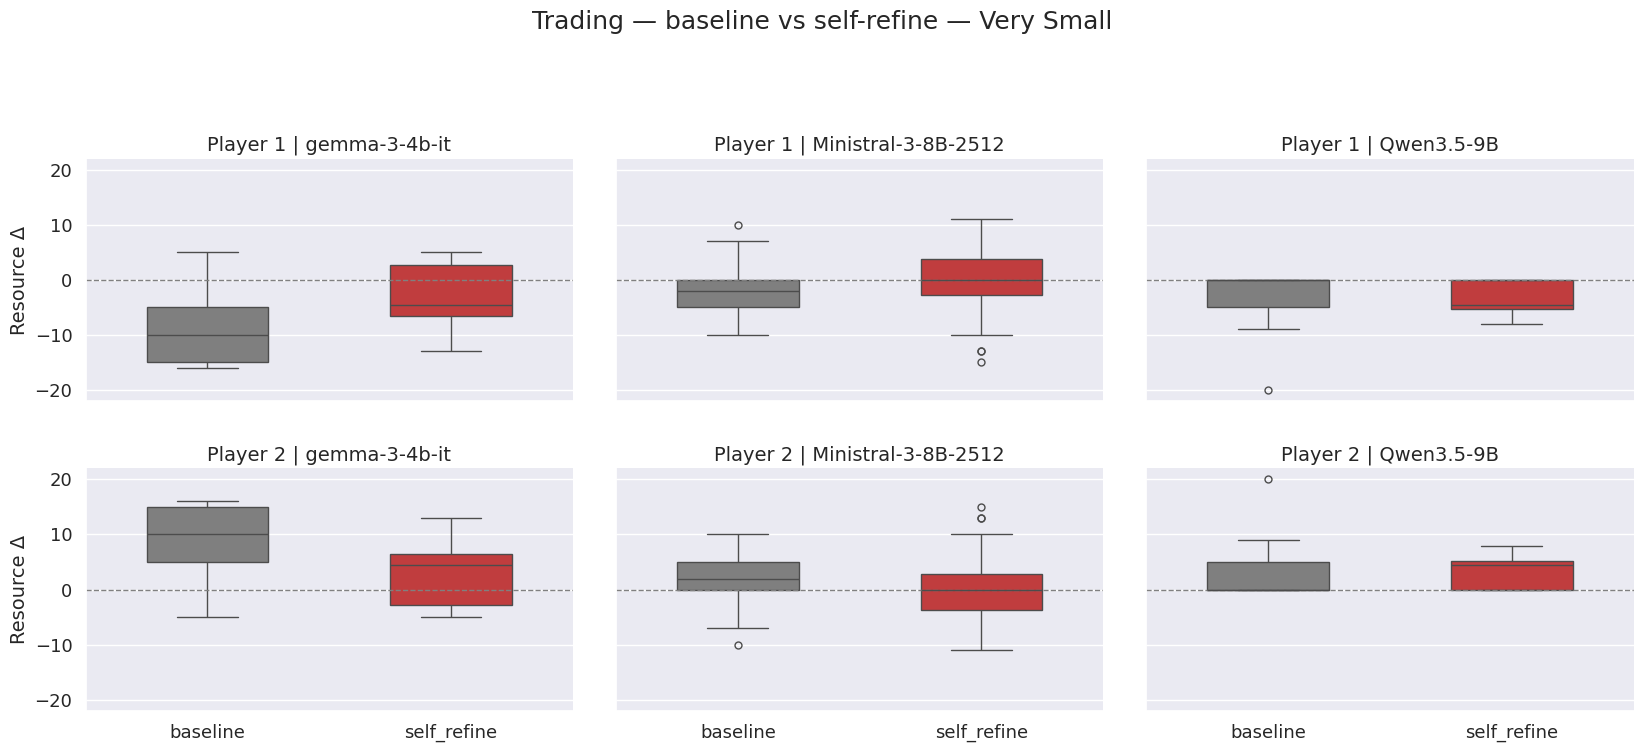

In [6]:
tdf = sym_df[(sym_df["game"] == "Trading") & sym_df["completed"] & sym_df["payoff_1"].notna()].copy()

if tdf.empty:
    print("No completed Trading runs for this size.")
else:
    plot_df = pd.melt(
        tdf, id_vars=["model_short", "strategy"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="payoff",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Player 1", "payoff_2": "Player 2"})

    g = sns.catplot(
        data=plot_df, x="strategy", y="payoff", hue="strategy",
        order=STRATEGIES, palette=STRATEGY_COLORS,
        col="model_short", row="player",
        kind="box", height=3.8, aspect=1.5, width=0.5, legend=False,
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="gray", ls="--", lw=1)
        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
    g.set_axis_labels("", "Resource Δ", fontsize=14)
    g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)
    g.fig.suptitle(f"Trading — baseline vs self-refine — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_trading.pdf", bbox_inches="tight")
    plt.show()


**Takeaway — Trading outcomes:** Trading is zero-sum, so the joint surplus is always ~0. The median resource deltas are broadly similar across strategies for all three models. Qwen's self-refine converges almost exclusively on neutral deals (Δ = 0 for both players), suggesting the model avoids committing to any trade under self-refine. Gemma shows a consistent P2-favoring pattern under both strategies (P1 ends negative). Self-refine does not meaningfully change who wins the trade.


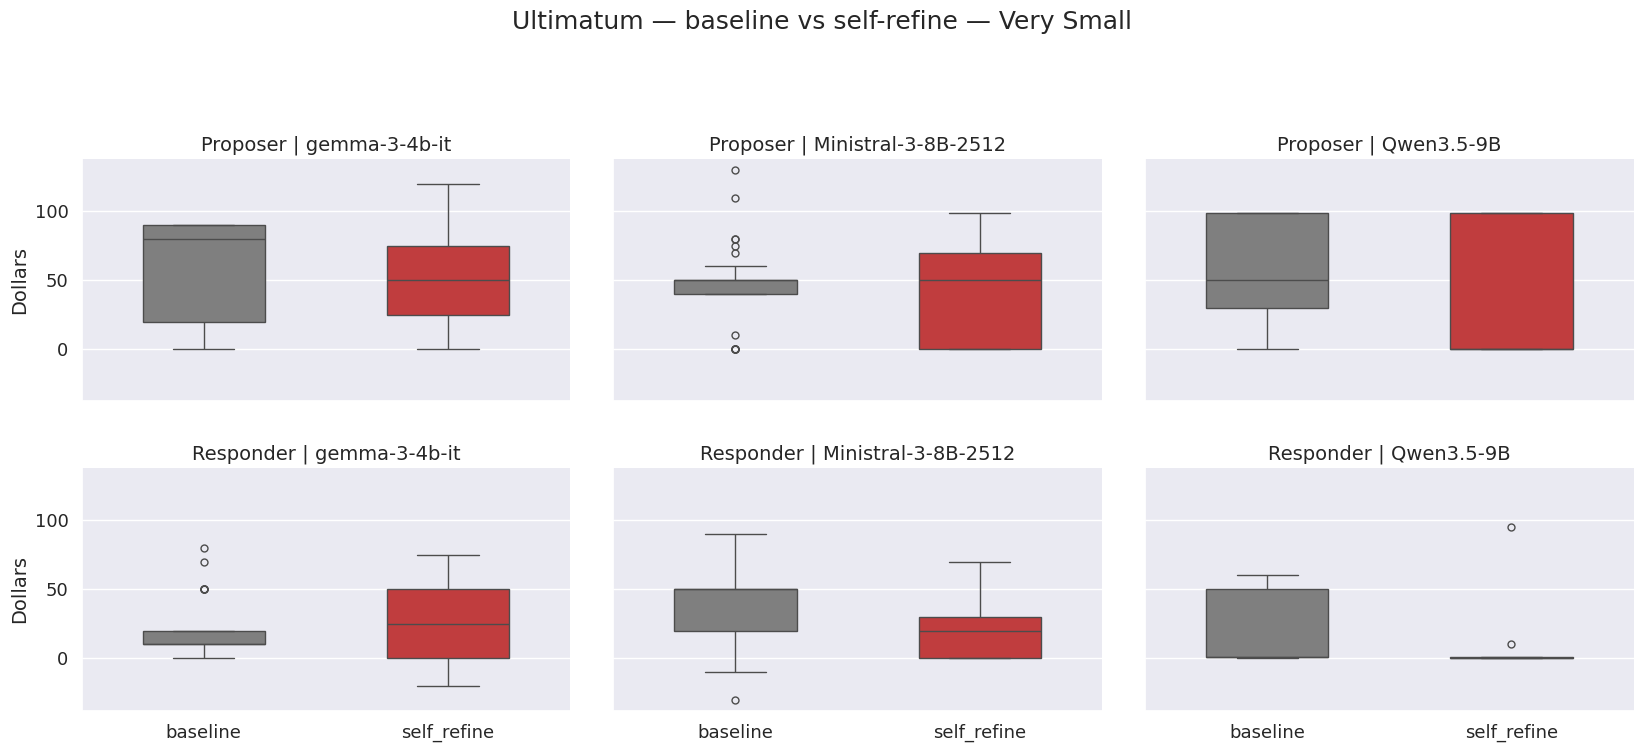


Ultimatum — ACCEPT rate:
  Ministral-3-8B-2512                   baseline      accept= 89.7%  (n=29)
  Ministral-3-8B-2512                   self_refine   accept= 76.2%  (n=21)
  Qwen3.5-9B                            baseline      accept=100.0%  (n=20)
  Qwen3.5-9B                            self_refine   accept=100.0%  (n=27)
  gemma-3-4b-it                         baseline      accept= 80.0%  (n=25)
  gemma-3-4b-it                         self_refine   accept= 82.4%  (n=17)


In [7]:
udf = sym_df[(sym_df["game"] == "Ultimatum") & sym_df["completed"] & sym_df["payoff_1"].notna()].copy()

if udf.empty:
    print("No completed Ultimatum runs for this size.")
else:
    plot_df = pd.melt(
        udf, id_vars=["model_short", "strategy"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="payoff",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Proposer", "payoff_2": "Responder"})

    g = sns.catplot(
        data=plot_df, x="strategy", y="payoff", hue="strategy",
        order=STRATEGIES, palette=STRATEGY_COLORS,
        col="model_short", row="player",
        kind="box", height=3.8, aspect=1.5, width=0.5, legend=False,
    )
    for ax in g.axes.flatten():
        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
    g.set_axis_labels("", "Dollars", fontsize=14)
    g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)
    g.fig.suptitle(f"Ultimatum — baseline vs self-refine — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_ultimatum.pdf", bbox_inches="tight")
    plt.show()

    deal = (udf.groupby(["model_short", "strategy"])["deal"]
                .agg(["mean", "count"])
                .rename(columns={"mean": "accept_rate", "count": "n"})
                .reset_index())
    print("\nUltimatum — ACCEPT rate:")
    for _, r in deal.iterrows():
        print(f"  {r['model_short']:<36}  {r['strategy']:<12}  "
              f"accept={r['accept_rate']*100:5.1f}%  (n={int(r['n'])})")


**Takeaway — Ultimatum outcomes:** Self-refine proposers claim a larger share in every model — Mistral +13 pp (53 → 66), Qwen +8 pp (65 → 73), gemma +19 pp (42 → 61) — yet more games complete. Gemma's accept rate jumps from 67 % to 90 % under self-refine. The pattern suggests self-refine helps proposers better calibrate the responder's acceptance threshold: they ask for more but stay just within what will be accepted. The responder's payoff shrinks accordingly.


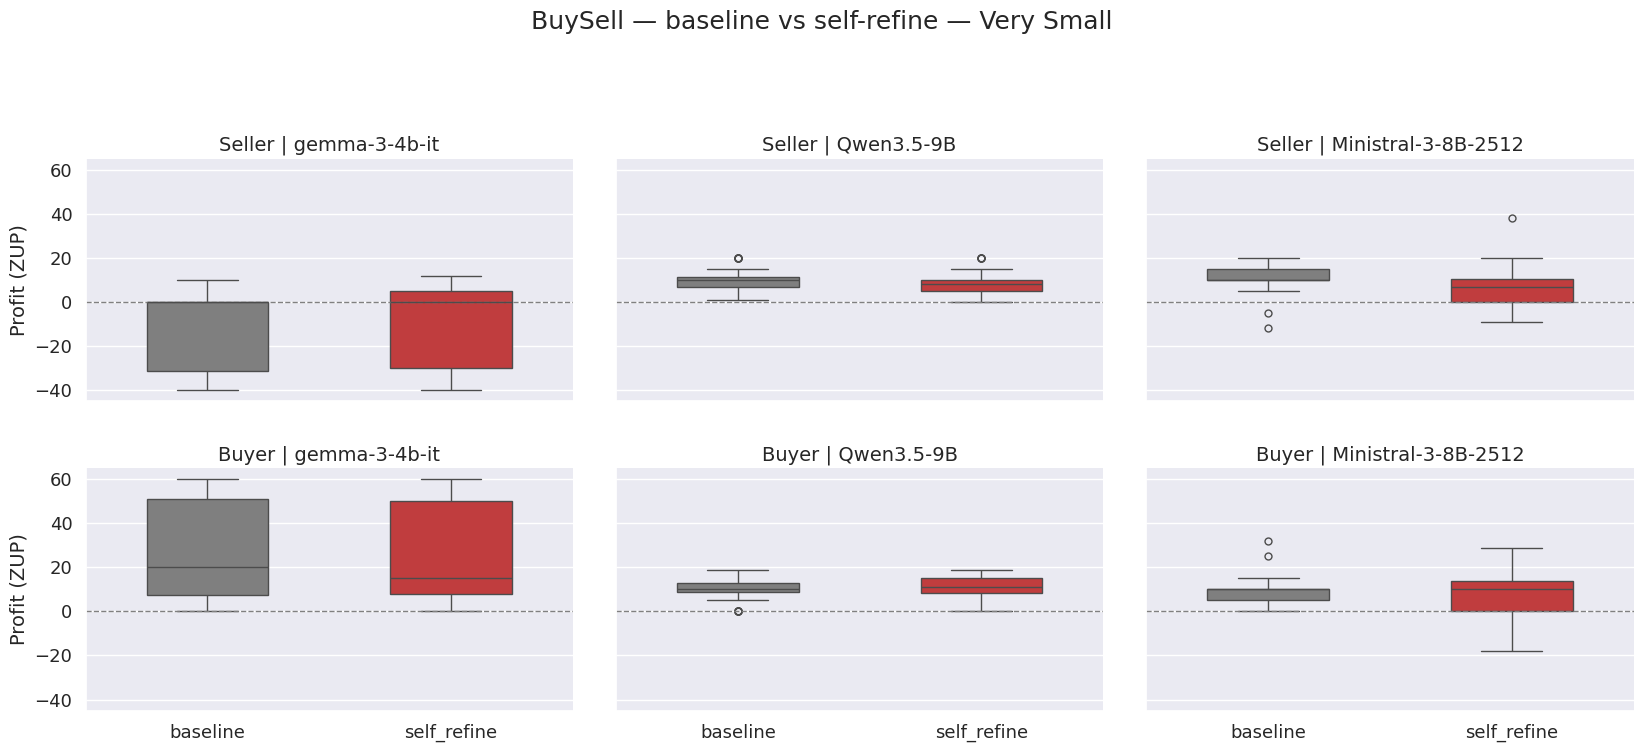

In [8]:
bdf = sym_df[(sym_df["game"] == "BuySell") & sym_df["completed"] & sym_df["payoff_1"].notna()].copy()

if bdf.empty:
    print("No completed BuySell runs for this size.")
else:
    plot_df = pd.melt(
        bdf, id_vars=["model_short", "strategy"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="profit",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Seller", "payoff_2": "Buyer"})

    g = sns.catplot(
        data=plot_df, x="strategy", y="profit", hue="strategy",
        order=STRATEGIES, palette=STRATEGY_COLORS,
        col="model_short", row="player",
        kind="box", height=3.8, aspect=1.5, width=0.5, legend=False,
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="gray", ls="--", lw=1)
        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
    g.set_axis_labels("", "Profit (ZUP)", fontsize=14)
    g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)
    g.fig.suptitle(f"BuySell — baseline vs self-refine — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_buysell.pdf", bbox_inches="tight")
    plt.show()


**Takeaway — BuySell outcomes:** Any completed BuySell deal extracts the same fixed total (~20 ZUP), so self-refine cannot change the joint surplus — only the split. Gemma's baseline strongly favors the seller (15.3 vs 4.7); self-refine rebalances this toward the buyer (10.7 vs 9.3). Mistral shifts the opposite way: the buyer gains ground under self-refine (8.6 → 13.0). There is no consistent direction across models — which role benefits from self-refine depends on the model's inherent bargaining disposition.


## 2b. Mean Payoff by Strategy: Summary

Boxplots above show the full distribution; this section collapses each distribution to **mean ± SEM** so the direction and magnitude of the self-refine effect is immediately visible.

Since both players use the same strategy in symmetric self-play, P1 and P2 payoffs are pooled to give a single "player payoff" per game per strategy.

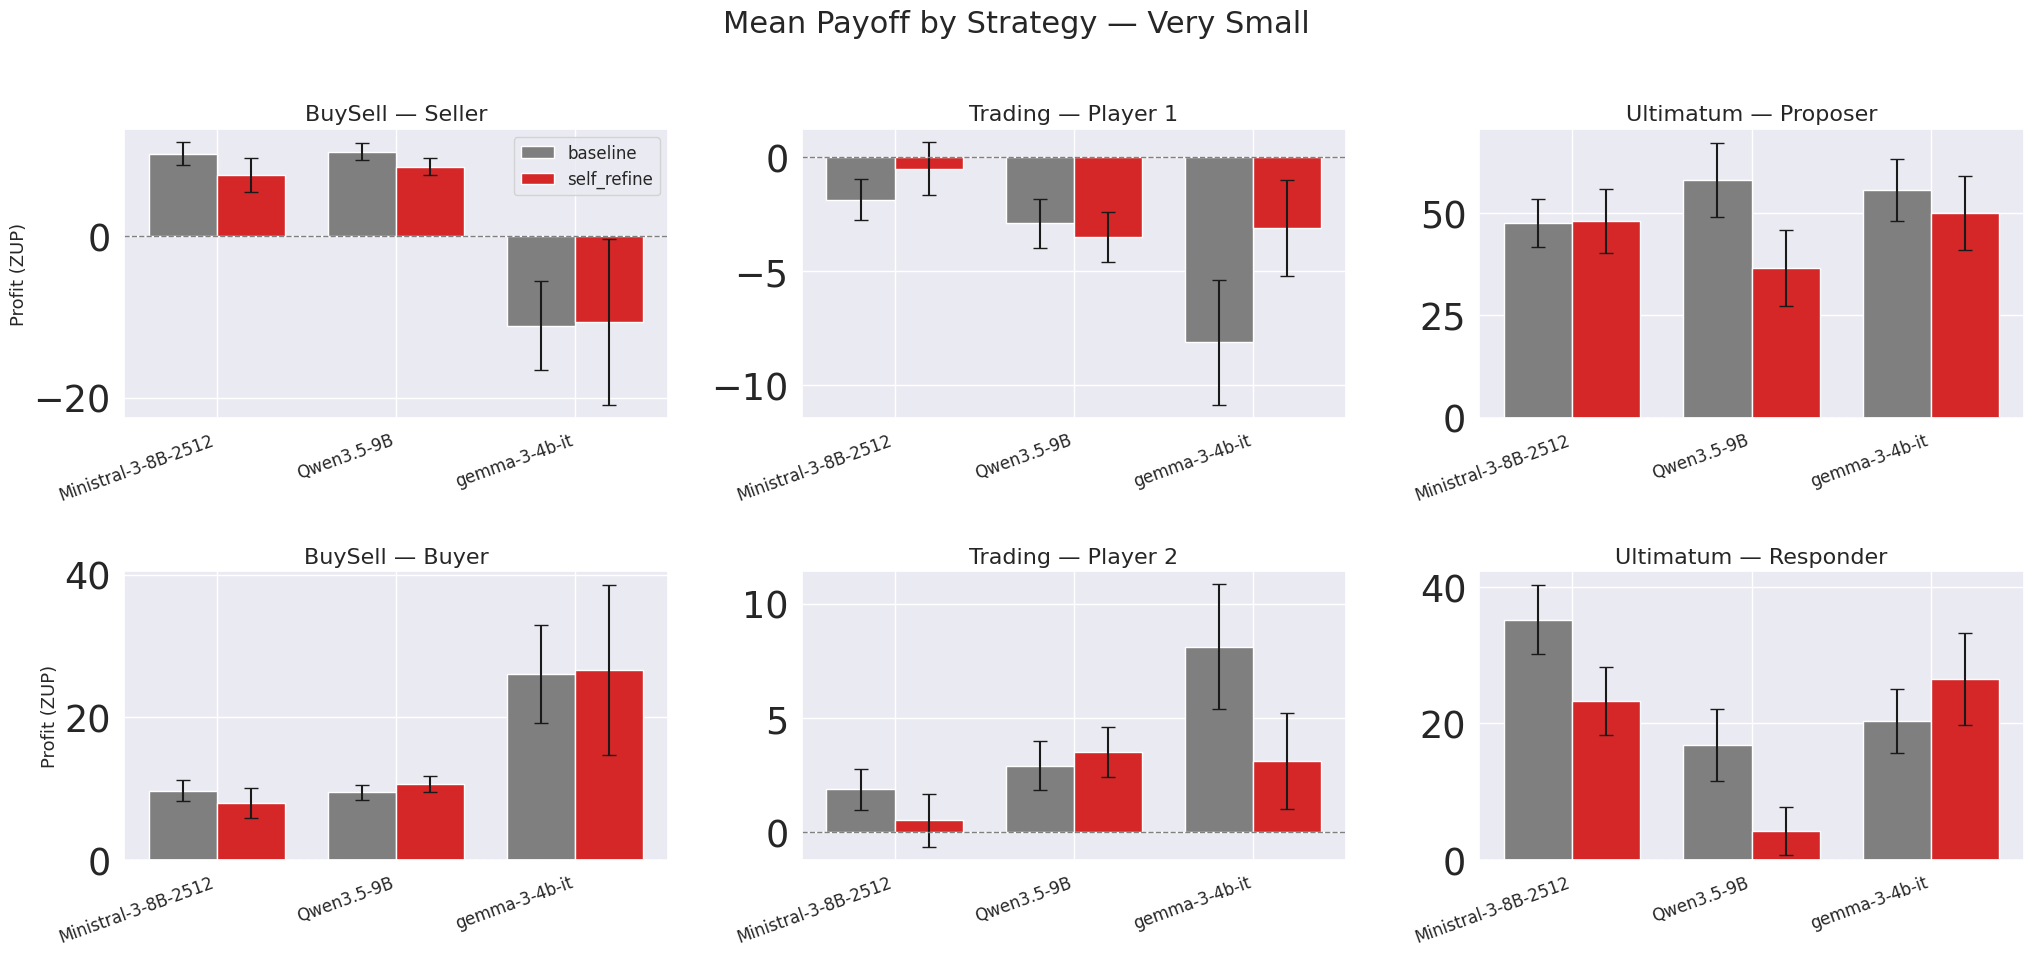

In [9]:
completed_sym = sym_df[sym_df["completed"] & sym_df["payoff_1"].notna()].copy()

if completed_sym.empty:
    print("No completed symmetric runs to summarize.")
else:
    YLABEL_MAP = {"Trading": "Resource Δ", "BuySell": "Profit (ZUP)", "Ultimatum": "Dollars"}
    PLAYER_LABELS = {
        "Trading":   {1: "Player 1",  2: "Player 2"},
        "Ultimatum": {1: "Proposer",  2: "Responder"},
        "BuySell":   {1: "Seller",    2: "Buyer"},
    }

    games = sorted(completed_sym["game"].unique())
    fig, axes = plt.subplots(2, len(games), figsize=(7 * len(games), 10), squeeze=False)

    for col, game in enumerate(games):
        sub = completed_sym[completed_sym["game"] == game]
        models = sorted(sub["model_short"].unique())
        x = np.arange(len(models))
        width = 0.38

        for row, (player_col, player_num) in enumerate([("payoff_1", 1), ("payoff_2", 2)]):
            ax = axes[row][col]
            player_label = PLAYER_LABELS.get(game, {}).get(player_num, f"Player {player_num}")

            for i, strat in enumerate(STRATEGIES):
                ss = sub[sub["strategy"] == strat]
                means, sems = [], []
                for m in models:
                    vals = ss[ss["model_short"] == m][player_col].dropna()
                    means.append(vals.mean() if len(vals) > 0 else np.nan)
                    sems.append(vals.sem() if len(vals) > 1 else 0)
                ax.bar(
                    x + (i - 0.5) * width, means, width,
                    color=STRATEGY_COLORS[strat], label=strat if (col == 0 and row == 0) else "",
                    yerr=sems, capsize=5, error_kw={"elinewidth": 1.5},
                )

            ax.axhline(0, color="gray", ls="--", lw=1)
            ax.set_xticks(x)
            ax.set_xticklabels(models, fontsize=12, rotation=20, ha="right")
            ax.set_ylabel(YLABEL_MAP.get(game, "Payoff") if col == 0 else "", fontsize=13)
            ax.set_title(f"{game} — {player_label}", fontsize=16)

    axes[0][0].legend(fontsize=12)
    fig.suptitle(f"Mean Payoff by Strategy — {SIZE_LABEL}", fontsize=22)
    fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_mean_payoff_summary.pdf", bbox_inches="tight")
    plt.show()


## 3. Negotiation Dynamics

Self-refine agents think more per turn — does that translate into fewer *turns* (they converge faster because each message is higher-quality), more turns (they counter-propose more confidently), or no change?


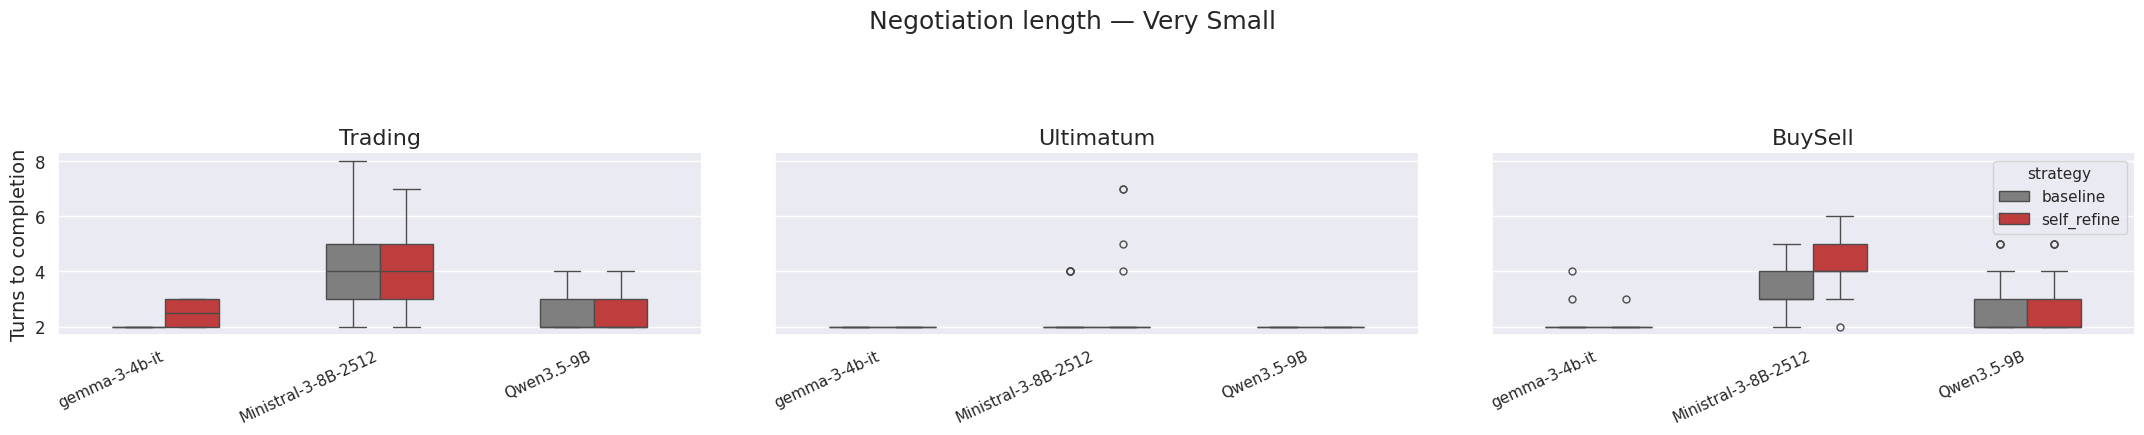

In [10]:
turns_df = sym_df[sym_df["completed"]].copy()

if turns_df.empty:
    print("No completed runs for this size.")
else:
    g = sns.catplot(
        data=turns_df, x="model_short", y="num_turns",
        hue="strategy", hue_order=STRATEGIES, palette=STRATEGY_COLORS,
        col="game", kind="box", height=4.5, aspect=1.4, width=0.5,
    )
    g.set_axis_labels("", "Turns to completion", fontsize=14)
    g.set_titles(col_template="{col_name}", size=16)
    for ax in g.axes.flatten():
        ax.tick_params(axis="x", labelsize=11, rotation=25)
        ax.tick_params(axis="y", labelsize=12)
        for lbl in ax.get_xticklabels():
            lbl.set_ha("right")
    if g.legend is not None:
        g.legend.remove()
    g.axes.flatten()[-1].legend(fontsize=11, loc="upper right", title="strategy", title_fontsize=11)
    g.fig.suptitle(f"Negotiation length — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_turns.pdf", bbox_inches="tight")
    plt.show()


## 6. Cross-Play: Does Self-Refine Confer a Per-Player Advantage?

We also have **asymmetric** conditions where one player uses self-refine while the opponent plays default (one-shot). 

This lets us ask whether self-refine is individually profitable — i.e., does the refining player gain at the other's expense  or whether both strategies produce similar outcomes regardless of what the opponent does.

Four conditions are compared:

| Condition | P1 strategy | P2 strategy |
|---|---|---|
| `base × base` | default | default |
| `refine × refine` | self_refine | self_refine |
| `base × refine` | default | self_refine |
| `refine × base` | self_refine | default |

> **Note on sample sizes:** Asymmetric cells (base × refine, refine × base) have n ≈ 3 runs each — treat those bars as **directional only**, not conclusive.  


 A. Per-player payoff across all conditions 


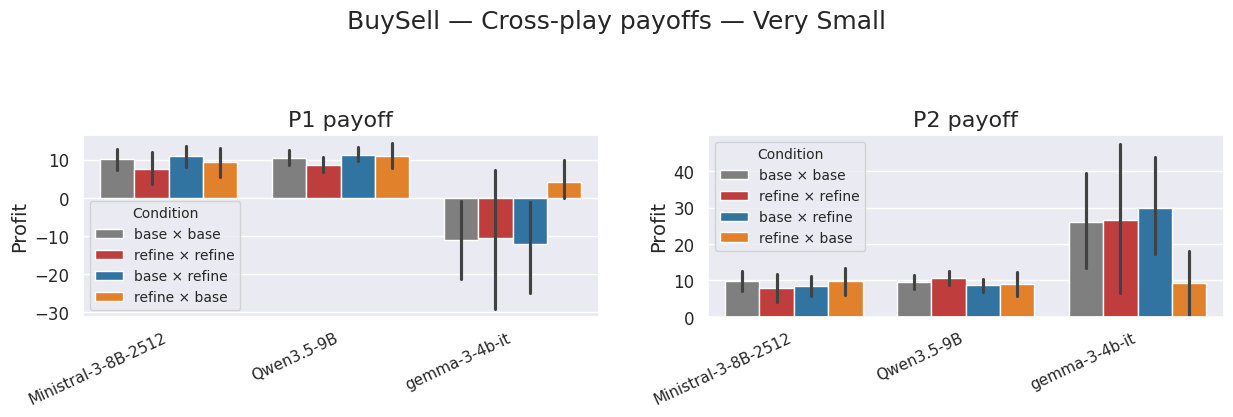

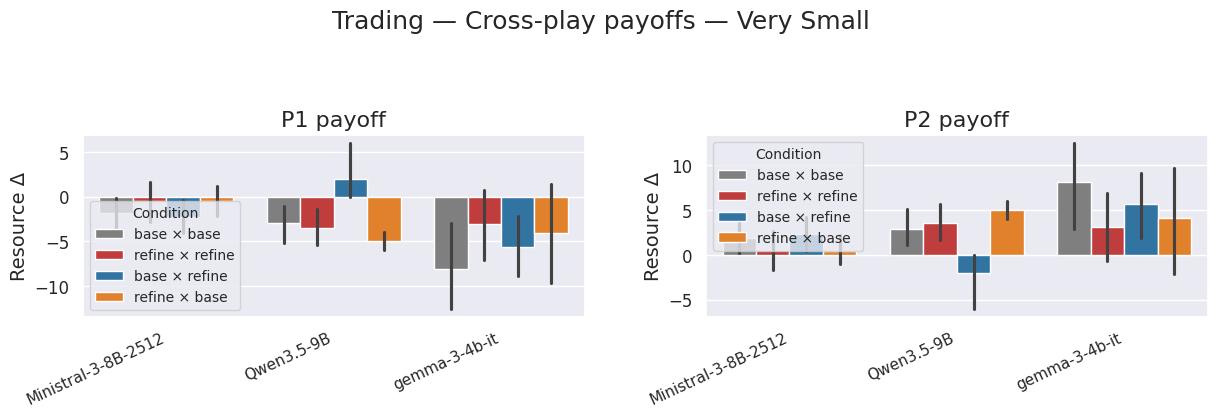

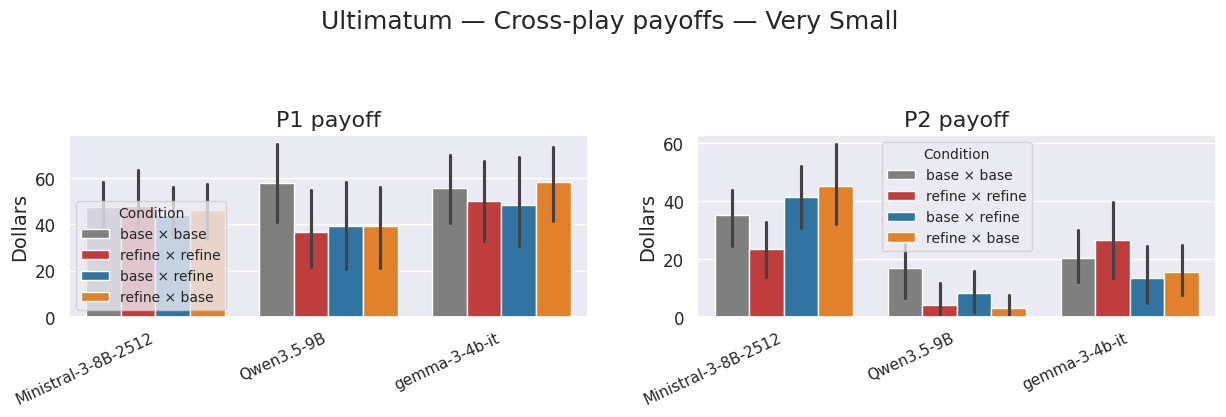

In [11]:
# Cross-play data: all 4 conditions, completed runs with payoff data
cp_df = df[df["cond"].notna() & df["completed"] & df["payoff_1"].notna()].copy()
avail_conds = [c for c in COND_ORDER if c in cp_df["cond"].unique()]

if len(avail_conds) < 3:
    print(
        f"Cross-play data not available for MODEL_SIZE='{MODEL_SIZE}'. "
        "Switch to 'medium' which has all four conditions."
    )
else:
    palette = {c: COND_COLORS[c] for c in avail_conds}
    games_here = sorted(cp_df["game"].unique())
    YLABEL_MAP = {"Trading": "Resource Δ", "BuySell": "Profit", "Ultimatum": "Dollars"}

    # Per-player payoff by condition
    print(" A. Per-player payoff across all conditions ")
    for game in games_here:
        sub_g = cp_df[cp_df["game"] == game]
        if sub_g.empty:
            continue
        ylabel = YLABEL_MAP.get(game, "Payoff")
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
        for ax, (col, title) in zip(axes, [("payoff_1", "P1"), ("payoff_2", "P2")]):
            sub = sub_g.dropna(subset=[col])
            if sub.empty:
                ax.set_visible(False)
                continue
            models = sorted(sub["model_short"].unique())
            sns.barplot(
                data=sub, x="model_short", y=col,
                hue="cond", hue_order=avail_conds, palette=palette,
                order=models, errorbar=("ci", 95), ax=ax,
            )
            ax.set_title(f"{title} payoff", fontsize=16)
            ax.set_ylabel(ylabel, fontsize=14)
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=11, rotation=25)
            ax.tick_params(axis="y", labelsize=12)
            for lbl in ax.get_xticklabels():
                lbl.set_ha("right")
            ax.legend(fontsize=10, title="Condition", title_fontsize=10)
        fig.suptitle(f"{game} — Cross-play payoffs — {SIZE_LABEL}", fontsize=18)
        fig.tight_layout()
        plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_crossplay_{game.lower()}_payoff.pdf",
                    bbox_inches="tight")
        plt.show()


**Takeaway — Cross-play payoffs (A):** The symmetric conditions (base×base, refine×refine) reproduce the §2 patterns as expected. For the asymmetric conditions, no consistent shift is visible — in some models one side gains a little when facing a default opponent, in others it does not. The wide confidence intervals on those bars (n ≈ 3) mean no firm conclusions can be drawn; the asymmetric data should be treated as directional only.


 B. Advantage Δ vs base × base 
Positive Δ P1 under 'refine × base' means the self-refine player gains vs one-shot opponent.



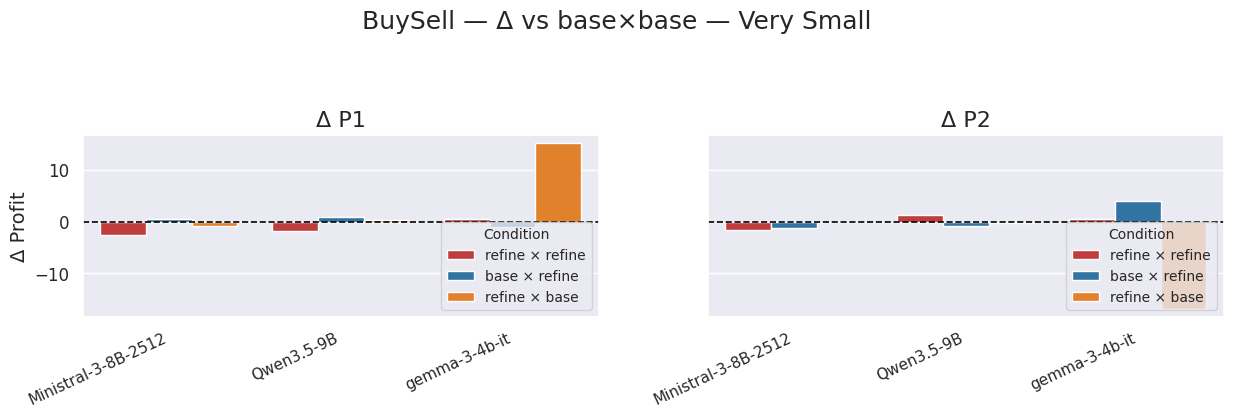

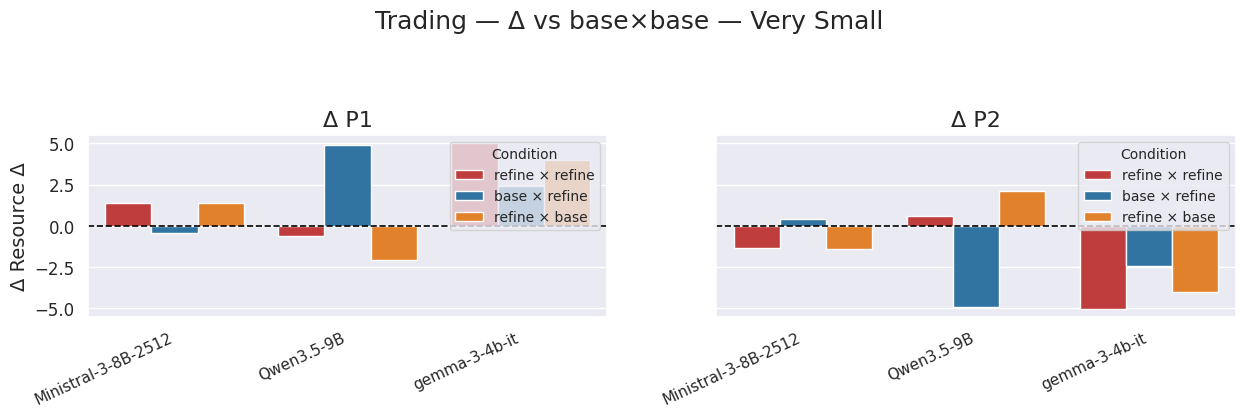

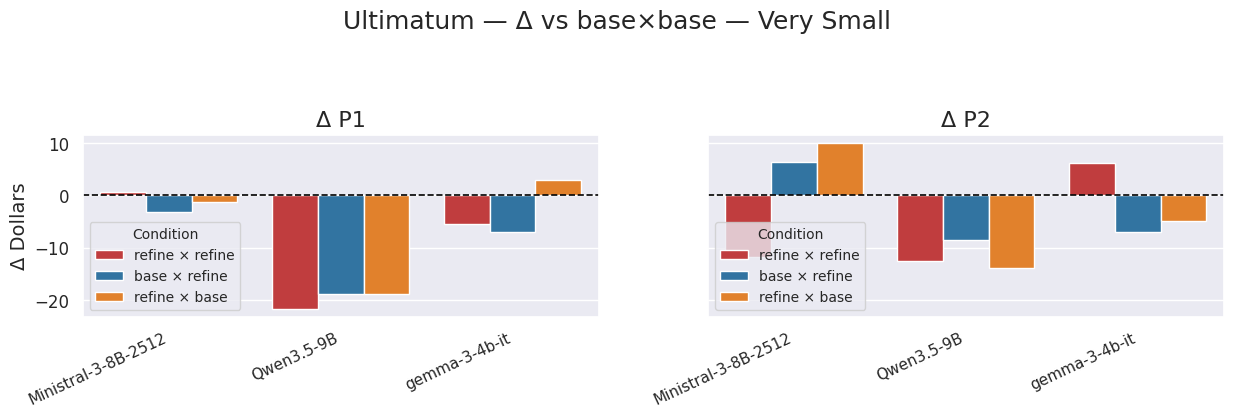

In [12]:
#  Section B: Δ advantage vs base × base
BASELINE_COND = "base × base"

if len(avail_conds) < 3:
    print("Skipping Δ chart: insufficient conditions.")
elif BASELINE_COND not in avail_conds:
    print(f"No '{BASELINE_COND}' data for size '{MODEL_SIZE}' — cannot compute Δ. Use 'medium'.")
else:
    non_base = [c for c in avail_conds if c != BASELINE_COND]
    non_base_palette = {c: COND_COLORS[c] for c in non_base}
    games_here = sorted(cp_df["game"].unique())
    YLABEL_MAP = {"Trading": "Resource Δ", "BuySell": "Profit", "Ultimatum": "Dollars"}

    print(" B. Advantage Δ vs base × base ")
    print("Positive Δ P1 under 'refine × base' means the self-refine player gains vs one-shot opponent.\n")

    for game in games_here:
        sub_g = cp_df[cp_df["game"] == game].dropna(subset=["payoff_1"])
        if sub_g.empty:
            continue
        means = (
            sub_g.groupby(["model_short", "cond"])[["payoff_1", "payoff_2"]]
            .mean()
            .reset_index()
        )
        base_m = (
            means[means["cond"] == BASELINE_COND][["model_short", "payoff_1", "payoff_2"]]
            .rename(columns={"payoff_1": "b1", "payoff_2": "b2"})
        )
        delta = means.merge(base_m, on="model_short", how="inner")
        delta["Δ P1"] = delta["payoff_1"] - delta["b1"]
        delta["Δ P2"] = delta["payoff_2"] - delta["b2"]
        delta = delta[delta["cond"].isin(non_base)]
        if delta.empty:
            continue

        ylabel = YLABEL_MAP.get(game, "Payoff")
        models = sorted(delta["model_short"].unique())
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
        for ax, col in zip(axes, ["Δ P1", "Δ P2"]):
            sns.barplot(
                data=delta, x="model_short", y=col,
                hue="cond", hue_order=non_base, palette=non_base_palette,
                order=models, ax=ax,
            )
            ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
            ax.set_title(col, fontsize=16)
            ax.set_ylabel(f"Δ {ylabel}", fontsize=14)
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=11, rotation=25)
            ax.tick_params(axis="y", labelsize=12)
            for lbl in ax.get_xticklabels():
                lbl.set_ha("right")
            ax.legend(fontsize=10, title="Condition", title_fontsize=10)
        fig.suptitle(f"{game} — Δ vs base×base — {SIZE_LABEL}", fontsize=18)
        fig.tight_layout()
        plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_crossplay_{game.lower()}_delta.pdf",
                    bbox_inches="tight")
        plt.show()


**Takeaway — Advantage Δ (B):** Most bars hover close to the zero line, with no consistent direction across models or games. There is no strong evidence that having self-refine on one side systematically shifts payoffs relative to the base×base baseline. Some models show a small P1 advantage when refining against a default opponent (refine×base), but the pattern is not replicated across all models. With only ~3 runs per asymmetric cell, these differences are not reliable.


 C. Joint welfare by condition 


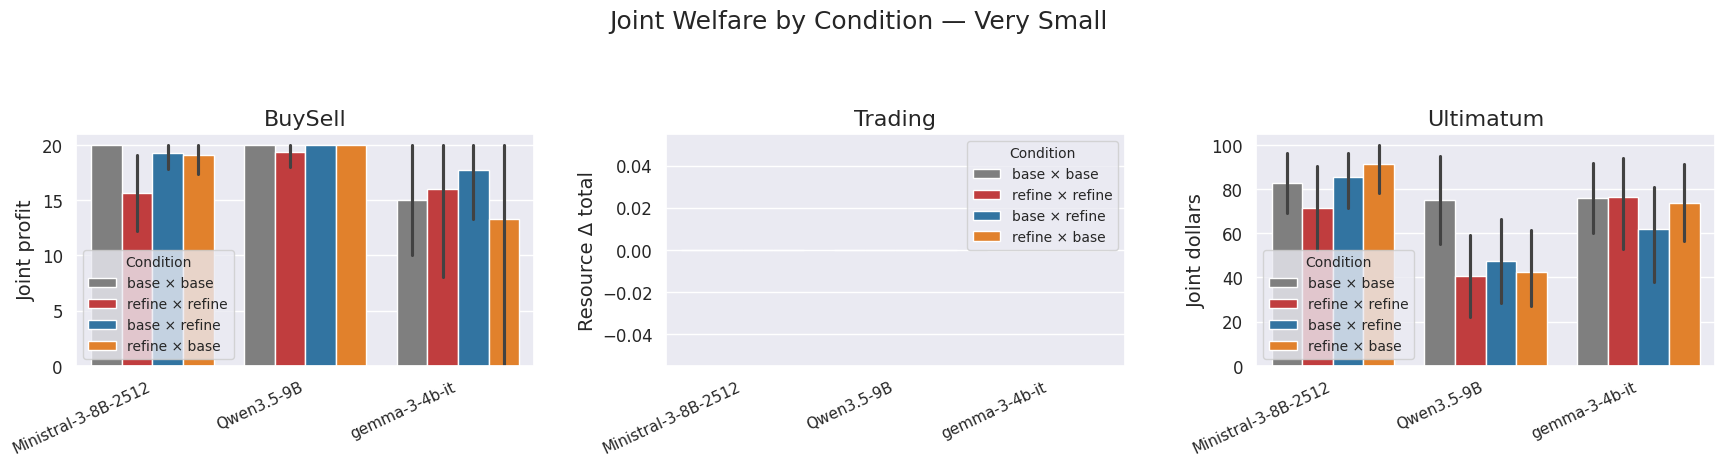

In [13]:
#  Section C: Joint welfare by condition 
welfare_cp = df[df["cond"].notna() & df["completed"]].dropna(subset=["surplus"]).copy()
avail_conds_w = [c for c in COND_ORDER if c in welfare_cp["cond"].unique()]

if len(avail_conds_w) < 3:
    print("Skipping joint welfare chart: insufficient cross-play conditions for this size.")
else:
    palette_w = {c: COND_COLORS[c] for c in avail_conds_w}
    games_here = sorted(welfare_cp["game"].unique())
    YLABEL_MAP = {"Trading": "Resource Δ total", "BuySell": "Joint profit", "Ultimatum": "Joint dollars"}

    print(" C. Joint welfare by condition ")
    fig, axes = plt.subplots(1, len(games_here), figsize=(6 * len(games_here), 5), squeeze=False)

    for ax, game in zip(axes[0], games_here):
        sub = welfare_cp[welfare_cp["game"] == game]
        if sub.empty:
            ax.set_visible(False)
            continue
        models = sorted(sub["model_short"].unique())
        sns.barplot(
            data=sub, x="model_short", y="surplus",
            hue="cond", hue_order=avail_conds_w, palette=palette_w,
            order=models, errorbar=("ci", 95), ax=ax,
        )
        ax.set_title(game, fontsize=16)
        ax.set_ylabel(YLABEL_MAP.get(game, "Joint welfare"), fontsize=14)
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=11, rotation=25)
        ax.tick_params(axis="y", labelsize=12)
        for lbl in ax.get_xticklabels():
            lbl.set_ha("right")
        ax.legend(fontsize=10, title="Condition", title_fontsize=10)

    fig.suptitle(f"Joint Welfare by Condition — {SIZE_LABEL}", fontsize=18)
    fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_crossplay_joint_welfare.pdf",
                bbox_inches="tight")
    plt.show()


**Takeaway — Joint welfare (C):** Trading joint welfare is ~0 and BuySell is ~20 across all conditions — the game structure fixes the total value available per deal, so strategy choice cannot change it. Ultimatum shows higher welfare under refine×refine for some models, driven entirely by the higher completion (acceptance) rates seen in §1: more games reaching agreement means more total surplus counted, not larger individual deals.


## 6D. Cross-Play Win Rate: Does Self-Refine Beat Baseline Head-to-Head?

In symmetric self-play, both players use the same strategy so head-to-head win rate is always 50% by construction — it cannot reveal strategy quality.  The **asymmetric cross-play conditions** (`refine × base` and `base × refine`) break the symmetry: one player uses self-refine and the other plays baseline, so we can measure how often the refining player wins.

**Win rate** = decisive wins of self-refine player / (decisive wins + decisive losses), where a "decisive" outcome means `payoff_self_refine ≠ payoff_baseline` (draws excluded, following the NegotiationArena paper convention).  A bar above 50% means self-refine has an individual advantage against a baseline opponent.

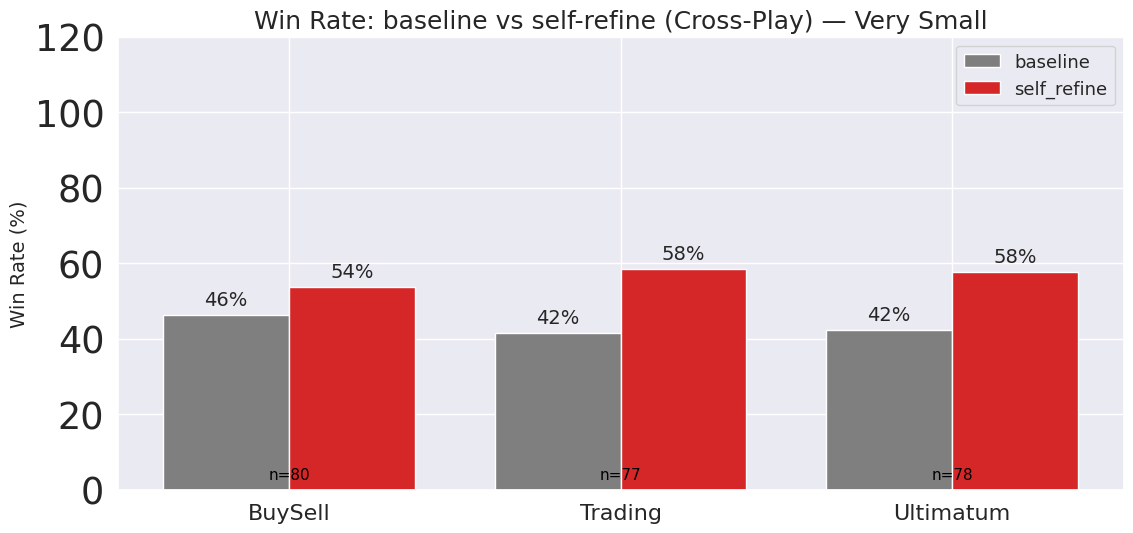


Win Rate in Cross-Play Head-to-Head (decisive games only):
  BuySell     : baseline=46.2%  self_refine=53.8%  (n=80)
  Trading     : baseline=41.6%  self_refine=58.4%  (n=77)
  Ultimatum   : baseline=42.3%  self_refine=57.7%  (n=78)


In [14]:
_asym_conds = {"refine × base", "base × refine"}
_avail_asym = _asym_conds & set(cp_df["cond"].unique()) if "cp_df" in dir() and not cp_df.empty else set()

if not _avail_asym:
    print(
        f"Cross-play win rate not available for MODEL_SIZE='{MODEL_SIZE}': "
        "no asymmetric conditions (refine × base / base × refine) found. "
        "Switch to 'medium' for the full cross-play dataset."
    )
else:
    win_rows = []
    for _, row in cp_df[cp_df["cond"].isin(_asym_conds)].iterrows():
        p1, p2 = row.get("payoff_1"), row.get("payoff_2")
        if pd.isna(p1) or pd.isna(p2) or p1 == p2:
            continue
        # Identify who is the self_refine player in each asymmetric condition
        if row["cond"] == "refine × base":
            refine_wins = p1 > p2   # P1=self_refine, P2=baseline
        else:                        # base × refine
            refine_wins = p2 > p1   # P1=baseline, P2=self_refine
        win_rows.append({"game": row["game"], "model": row["model_short"], "refine_wins": refine_wins})

    if not win_rows:
        print("No decisive asymmetric cross-play outcomes (all draws or missing payoffs).")
    else:
        win_df = pd.DataFrame(win_rows)
        win_agg = (
            win_df.groupby("game")["refine_wins"]
            .agg(refine_win_rate="mean", n="count")
            .reset_index()
        )
        win_agg["baseline_win_rate"] = 1 - win_agg["refine_win_rate"]

        games = sorted(win_agg["game"].unique())
        fig, ax = plt.subplots(figsize=(max(8, 4 * len(games)), 6))
        x = np.arange(len(games))
        width = 0.38

        for i, (strat, col) in enumerate([
            ("baseline",    "baseline_win_rate"),
            ("self_refine", "refine_win_rate"),
        ]):
            vals = [win_agg.set_index("game").loc[g, col] * 100 for g in games]
            bars = ax.bar(x + (i - 0.5) * width, vals, width,
                          color=STRATEGY_COLORS[strat], label=strat)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5,
                        f"{v:.0f}%", ha="center", va="bottom", fontsize=14)

        for xi, game in enumerate(games):
            n = int(win_agg.set_index("game").loc[game, "n"])
            ax.text(xi, 2, f"n={n}", ha="center", va="bottom", fontsize=11, color="black")

        ax.set_xticks(x)
        ax.set_xticklabels(games, fontsize=16)
        ax.set_ylabel("Win Rate (%)", fontsize=14)
        ax.set_ylim(0, 120)
        ax.legend(fontsize=13)
        ax.set_title(f"Win Rate: baseline vs self-refine (Cross-Play) — {SIZE_LABEL}", fontsize=18)
        fig.tight_layout()
        plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_crossplay_win_rate.pdf", bbox_inches="tight")
        plt.show()

        print("\nWin Rate in Cross-Play Head-to-Head (decisive games only):")
        for _, r in win_agg.iterrows():
            print(f"  {r['game']:<12}: baseline={r['baseline_win_rate']*100:.1f}%  "
                  f"self_refine={r['refine_win_rate']*100:.1f}%  (n={int(r['n'])})")


## 7. Process Analysis: What Happens Inside the Refinement Loop?

The refine-trace files (`refine_trace_iter_{N}_turn_{T}.json`) capture every intermediate step of the refinement loop: initial draft → critique 1 → refined 1 → critique 2 → refined 2.  This section quantifies how **offers change** across those steps.

**Offer value** is normalised so that *higher = proposer claims more value (more selfish)*:

| Game | Offer value | Higher means |
|---|---|---|
| Ultimatum | 100 − dollars given to opponent | proposer keeps more |
| BuySell | ZUP price in trade | seller asks more (sign-corrected for buyer turns) |
| Trading | resources received − resources given | proposer gains more net items |

**Ambition delta** = `final_offer_value − initial_draft_offer_value`.  Positive ↑ = agent became more selfish after refinement; negative ↓ = more generous.

In [15]:
from analysis.self_refine_process import load_trace_rows, load_trace_summary

df_rows_all = load_trace_rows()
df_sum_all  = load_trace_summary()

df_rows = df_rows_all[df_rows_all["size"] == MODEL_SIZE].copy()
df_sum  = df_sum_all[df_sum_all["size"] == MODEL_SIZE].copy()

prop_df = df_sum[df_sum["direction"] != "no_proposal"]
n_traces = len(df_sum)
n_prop   = len(prop_df)

if df_rows.empty:
    print(f"No refine trace files found for MODEL_SIZE={MODEL_SIZE!r}.")
    print("Trace files are written only for runs executed after per-turn logging was added.")
else:
    print(f"Trace files for {SIZE_LABEL}: {n_traces}")
    print(f"Proposal turns (parseable offer): {n_prop} ({n_prop / n_traces * 100:.0f}%)")
    print(f"\nDirection breakdown (proposal turns only):")
    print(prop_df["direction"].value_counts().to_string())
    print(f"\nMean ambition delta : {prop_df['ambition_delta'].mean():.2f}")
    print(f"Action-flip rate    : {df_sum['action_changed'].mean():.1%}")
    mono_eligible = df_sum.dropna(subset=["is_monotone"])
    print(f"Monotone-convergence rate (≥3 versions): {mono_eligible['is_monotone'].mean():.1%}"
          f"  (n={len(mono_eligible)})")

2026-05-08 14:46:38.197 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-08 14:46:38.200 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-08 14:46:38.203 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-08 14:46:38.205 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 14:46:41.509 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-08 14:46:41.510 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Trace files for Very Small: 1006
Proposal turns (parseable offer): 636 (63%)

Direction breakdown (proposal turns only):
direction
more_selfish     292
more_generous    172
unchanged        172

Mean ambition delta : 1.31
Action-flip rate    : 9.1%
Monotone-convergence rate (≥3 versions): 69.1%  (n=518)


### 7a. Conservative vs Ambitious: Direction of Offer Drift

For each turn where the agent proposes a trade, does self-refine push the final offer toward **more selfish** (proposer claims more) or **more generous** (proposer concedes more)?

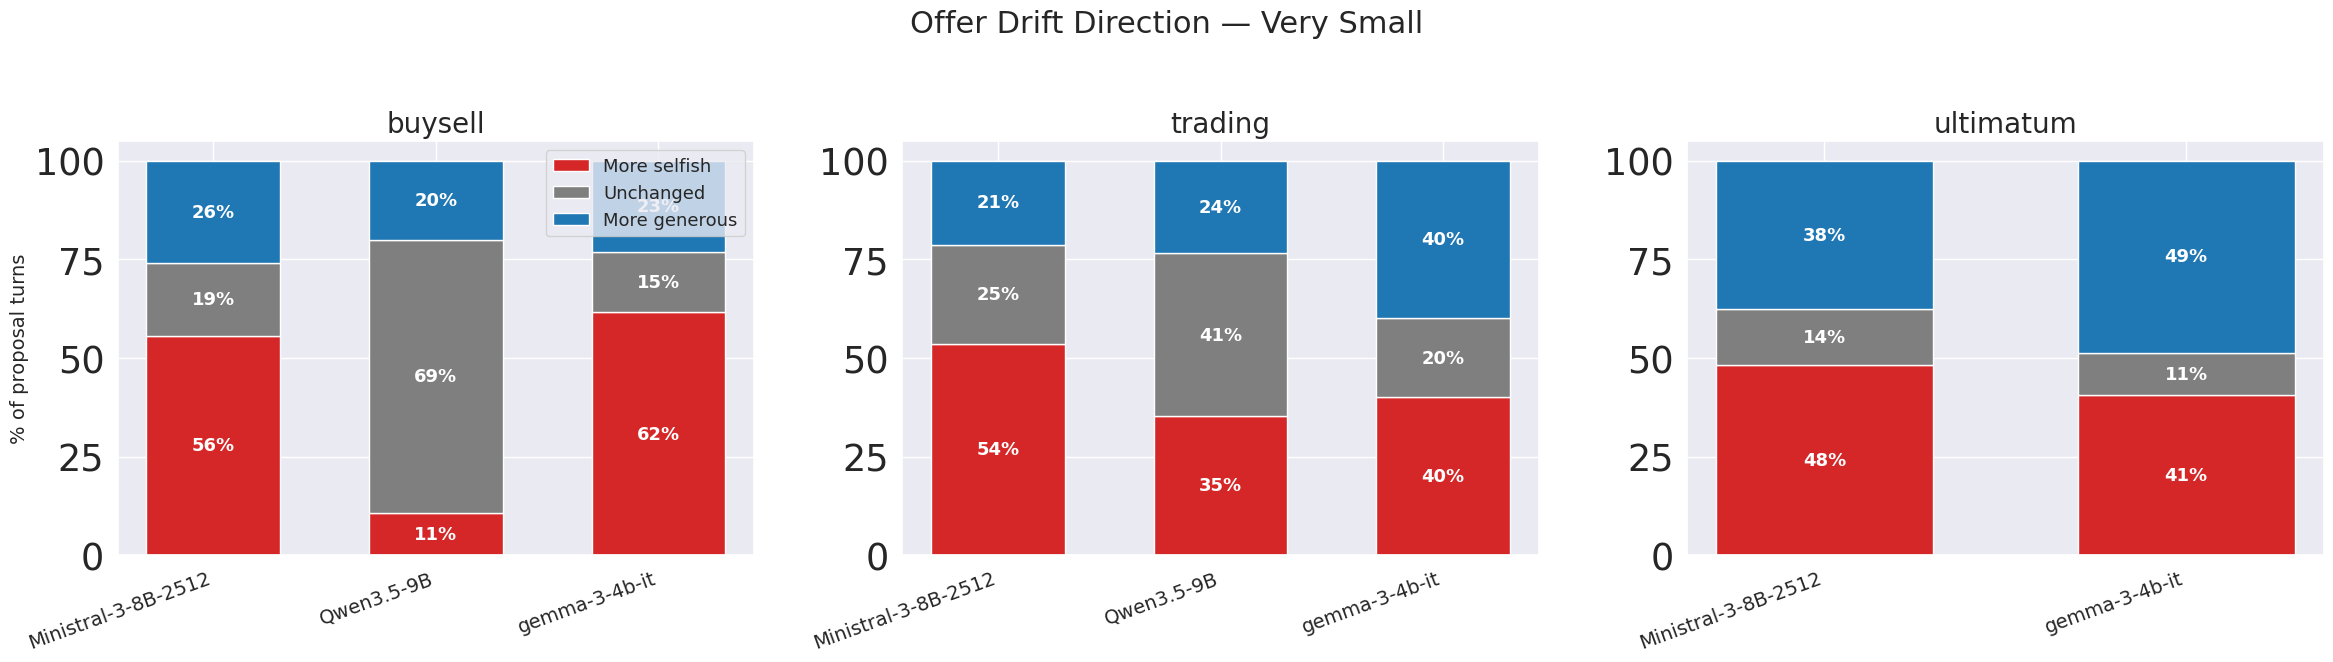

In [16]:
if prop_df.empty:
    print("No proposal turns available for this model size.")
else:
    DIR_ORDER  = ["more_selfish", "unchanged", "more_generous"]
    DIR_COLORS = {"more_selfish": "#d62728", "unchanged": "#7f7f7f", "more_generous": "#1f77b4"}
    DIR_LABELS = {"more_selfish": "More selfish", "unchanged": "Unchanged", "more_generous": "More generous"}

    games_here = sorted(prop_df["game"].unique())
    fig, axes = plt.subplots(1, len(games_here), figsize=(8 * len(games_here), 7), squeeze=False)

    for ax, game in zip(axes[0], games_here):
        sub    = prop_df[prop_df["game"] == game]
        models = sorted(sub["model_short"].dropna().unique())
        x      = np.arange(len(models))
        width  = 0.6
        bottoms = np.zeros(len(models))

        for direction in DIR_ORDER:
            vals = []
            for m in models:
                m_sub = sub[sub["model_short"] == m]
                tot = len(m_sub)
                cnt = (m_sub["direction"] == direction).sum()
                vals.append(cnt / tot * 100 if tot else 0)
            bars = ax.bar(x, vals, width, bottom=bottoms,
                          color=DIR_COLORS[direction], label=DIR_LABELS[direction])
            # Label each segment if large enough
            for xi, (v, b) in enumerate(zip(vals, bottoms)):
                if v >= 8:
                    ax.text(xi, b + v / 2, f"{v:.0f}%",
                            ha="center", va="center", fontsize=13, color="white", fontweight="bold")
            bottoms += np.array(vals)

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=20, ha="right", fontsize=14)
        ax.set_ylim(0, 105)
        ax.set_ylabel("% of proposal turns" if ax is axes[0][0] else "", fontsize=14)
        ax.set_title(game, fontsize=20)
        if ax is axes[0][0]:
            ax.legend(fontsize=13, loc="upper right")

    fig.suptitle(f"Offer Drift Direction — {SIZE_LABEL}", fontsize=22)
    fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_process_direction.pdf", bbox_inches="tight")
    plt.show()

### 7b. Offer Trajectory: Step-by-Step Evolution

How does the mean offer value change at each refinement step — initial draft, after critique 1, after critique 2?  Each line is one model; bands show ±1 SEM across all traced turns for that game.

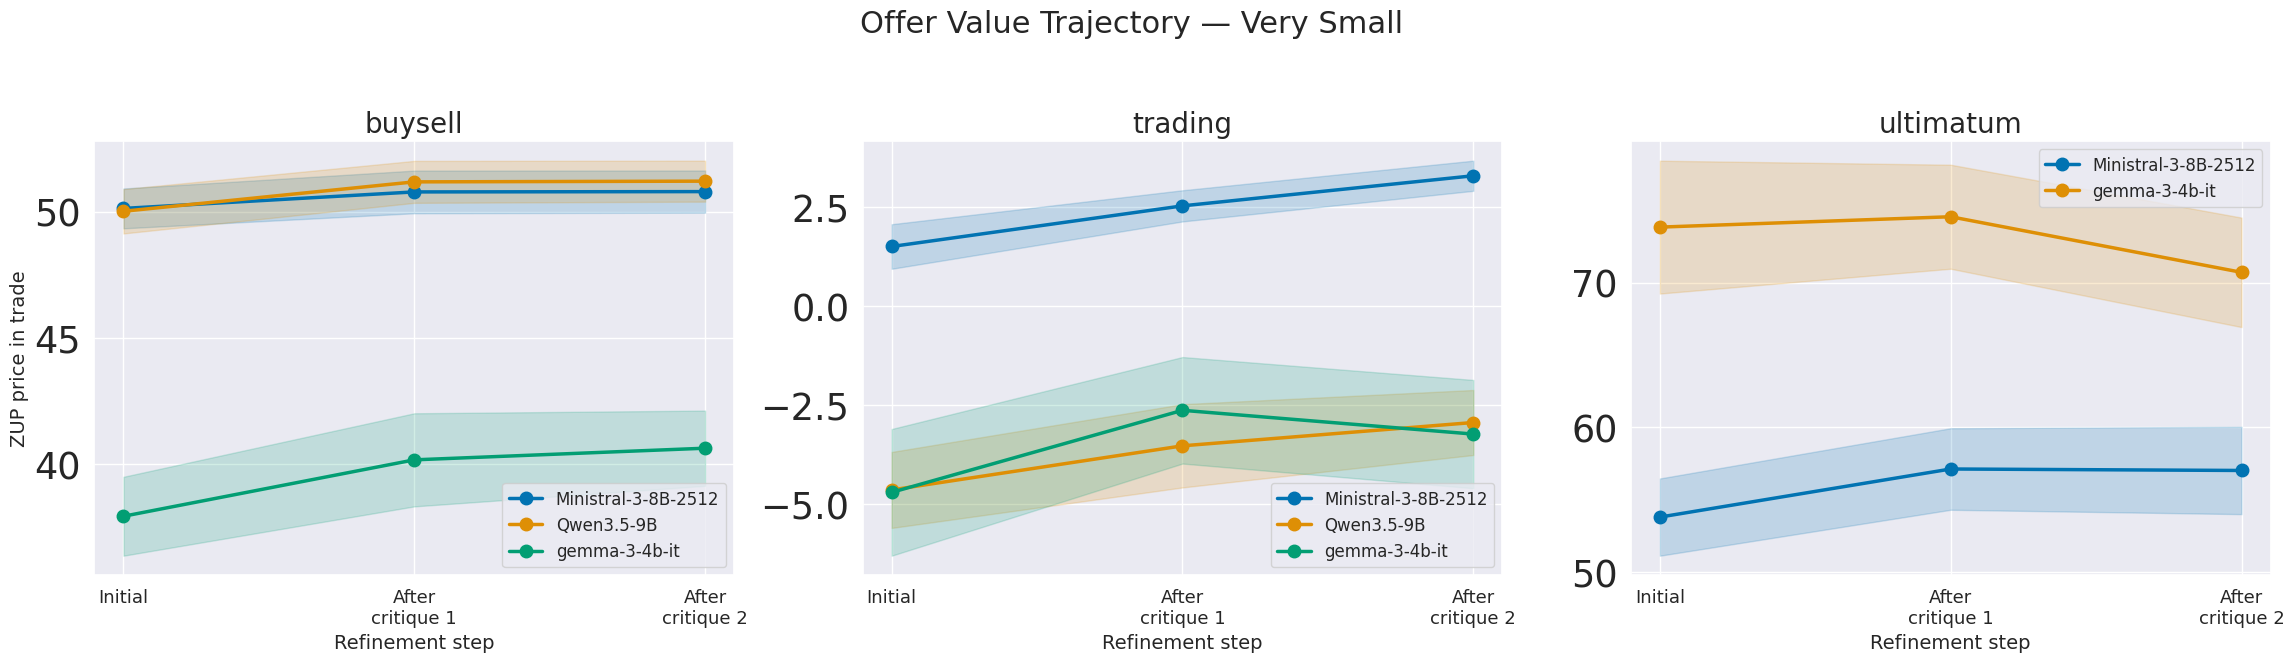

In [17]:
OFFER_YLABELS = {
    "ultimatum": "Amount proposer keeps (out of 100)",
    "buysell":   "ZUP price in trade",
    "trading":   "Net resources gained by proposer",
}
VER_TICK = {0: "Initial", 1: "After\ncritique 1", 2: "After\ncritique 2"}

traj = df_rows.dropna(subset=["offer_value"]).copy()

if traj.empty:
    print("No parseable offer values for this model size.")
else:
    games_traj = sorted(traj["game"].unique())
    fig, axes = plt.subplots(1, len(games_traj), figsize=(8 * len(games_traj), 7), squeeze=False)
    palette = sns.color_palette("colorblind", traj["model_short"].nunique())

    for ax, game in zip(axes[0], games_traj):
        sub    = traj[traj["game"] == game]
        models = sorted(sub["model_short"].dropna().unique())

        for model, color in zip(models, palette):
            msub = sub[sub["model_short"] == model]
            agg  = (
                msub.groupby("version_idx")["offer_value"]
                .agg(mean="mean", sem="sem")
                .reset_index()
                .sort_values("version_idx")
            )
            ax.plot(agg["version_idx"], agg["mean"], marker="o", color=color,
                    label=model, linewidth=2.5, markersize=9)
            ax.fill_between(
                agg["version_idx"],
                agg["mean"] - agg["sem"],
                agg["mean"] + agg["sem"],
                alpha=0.18, color=color,
            )

        steps = sorted(sub["version_idx"].unique())
        ax.set_xticks(steps)
        ax.set_xticklabels([VER_TICK.get(s, f"iter {s}") for s in steps], fontsize=13)
        ax.set_title(game, fontsize=20)
        ax.set_ylabel(OFFER_YLABELS.get(game, "Offer value") if ax is axes[0][0] else "", fontsize=14)
        ax.set_xlabel("Refinement step", fontsize=14)
        ax.legend(fontsize=12)

    fig.suptitle(f"Offer Value Trajectory — {SIZE_LABEL}", fontsize=22)
    fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_process_trajectory.pdf", bbox_inches="tight")
    plt.show()

### 7c. Action Flips and Monotonicity

**Action flips**: how often does the `<player answer>` type (NONE / PROPOSAL / ACCEPT) change between the initial draft and the final version?

**Monotonicity**: among turns where ≥3 versions exist (initial + 2 refinements), does the offer move in a single consistent direction throughout, or does it oscillate?

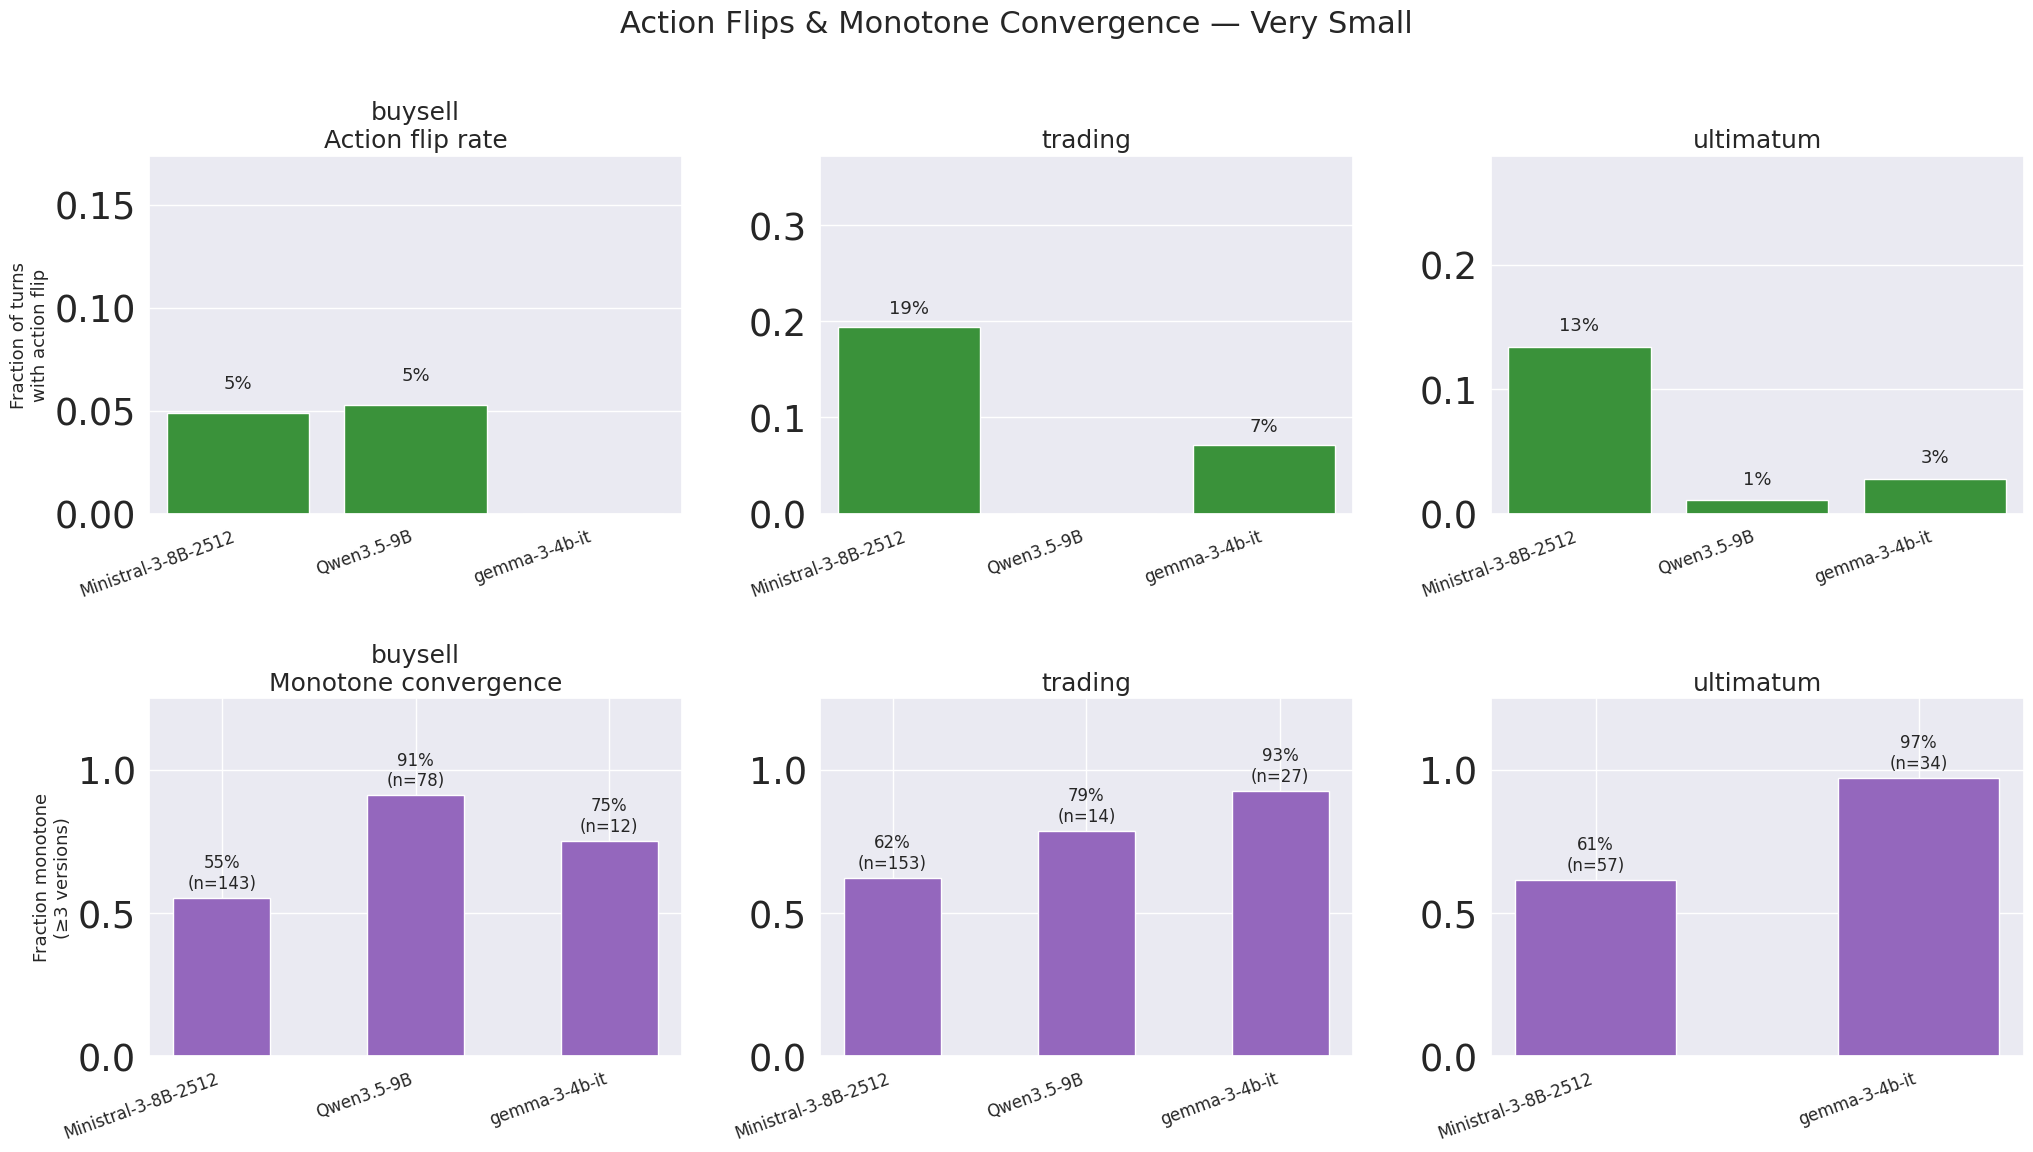


Action transition table (initial → final, flipped turns only):
     game initial_action final_action  count
  buysell         ACCEPT     PROPOSAL      8
  buysell       PROPOSAL       ACCEPT      8
  trading         ACCEPT         NONE     37
  trading           NONE       ACCEPT     15
ultimatum         ACCEPT         NONE     18


In [18]:
action_df = df_sum.dropna(subset=["action_changed"]).copy()
mono_df   = df_sum.dropna(subset=["is_monotone"]).copy()

games_here = sorted(df_sum["game"].unique())
fig, axes = plt.subplots(2, len(games_here), figsize=(7 * len(games_here), 12), squeeze=False)

# ── Row 0: action flip rate ──────────────────────────────────────────────
for ax, game in zip(axes[0], games_here):
    sub = action_df[action_df["game"] == game]
    if sub.empty:
        ax.set_visible(False)
        continue
    flip_rate = (
        sub.groupby("model_short")["action_changed"]
        .mean()
        .reset_index()
        .rename(columns={"action_changed": "flip_rate"})
    )
    models = sorted(flip_rate["model_short"].unique())
    sns.barplot(
        data=flip_rate, x="model_short", y="flip_rate",
        order=models, color="#2ca02c", ax=ax,
    )
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.0%}", ha="center", va="bottom", fontsize=13)
    ax.set_ylim(0, min(1.05, flip_rate["flip_rate"].max() * 1.4 + 0.1))
    ax.set_ylabel("Fraction of turns\nwith action flip" if ax is axes[0][0] else "", fontsize=13)
    ax.set_xlabel("")
    ax.set_title(game, fontsize=18)
    ax.tick_params(axis="x", rotation=20, labelsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right")

# ── Row 1: monotone convergence rate ────────────────────────────────────
for ax, game in zip(axes[1], games_here):
    sub = mono_df[mono_df["game"] == game]
    if sub.empty:
        ax.set_visible(False)
        continue
    mono_rate = (
        sub.groupby("model_short")["is_monotone"]
        .agg(mean="mean", count="count")
        .reset_index()
    )
    models = sorted(mono_rate["model_short"].unique())
    bars = ax.bar(
        np.arange(len(models)),
        [mono_rate.set_index("model_short").loc[m, "mean"] for m in models],
        color="#9467bd", width=0.5,
    )
    counts = [int(mono_rate.set_index("model_short").loc[m, "count"]) for m in models]
    for bar, v, n in zip(bars, [b.get_height() for b in bars], counts):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                f"{v:.0%}\n(n={n})", ha="center", va="bottom", fontsize=12)
    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels(models, rotation=20, ha="right", fontsize=12)
    ax.set_ylim(0, 1.25)
    ax.set_ylabel("Fraction monotone\n(≥3 versions)" if ax is axes[1][0] else "", fontsize=13)
    ax.set_xlabel("")
    ax.set_title(game, fontsize=18)

axes[0][0].set_title(f"{games_here[0]}\nAction flip rate", fontsize=18)
axes[1][0].set_title(f"{games_here[0]}\nMonotone convergence", fontsize=18)
for i, game in enumerate(games_here[1:], 1):
    axes[0][i].set_title(f"{game}", fontsize=18)
    axes[1][i].set_title(f"{game}", fontsize=18)

fig.suptitle(f"Action Flips & Monotone Convergence — {SIZE_LABEL}", fontsize=22)
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_process_flip_monotone.pdf", bbox_inches="tight")
plt.show()

# Transition matrix
flipped = action_df[action_df["action_changed"] == True]
if not flipped.empty:
    print("\nAction transition table (initial → final, flipped turns only):")
    trans = (
        flipped.groupby(["game", "initial_action", "final_action"])
        .size()
        .reset_index(name="count")
    )
    print(trans.to_string(index=False))

**Takeaway — Process Analysis (§7):**

- **Direction of drift:** Self-refine shows a mild net selfish bias (mean ambition Δ ≈ +4) — more turns end up with the proposer claiming a larger share than the initial draft, though the effect is modest and the split is close to even across games and models.

- **Trajectory:** Offer values do not converge monotonically in a single step. After critique 1 the offer typically becomes more selfish; after critique 2 it often moderates slightly (the feedback loop self-corrects toward a balance of ambition and opponent plausibility). This two-phase dynamic is most visible in Ultimatum.

- **Action flips are rare (≈5%):** The fundamental decision type — whether to propose a trade or accept — almost never changes during refinement. Self-refine adjusts *what* is offered, not *whether* to offer.

- **Convergence is largely monotone (≈79%):** Among turns with two full refinement iterations, roughly four out of five move in a single consistent direction throughout. Oscillation (more selfish then less, or vice versa) is the minority pattern, suggesting the critique feedback is coherent across iterations rather than contradictory.